#**人工智慧在商情預測的應用**
本篇主要整合課堂上所學習到的 **Pandas、NumPy、Matplotlib、Seaborn、Scikit-learn**以及 **TensorFlow/Keras** 等資料科學與深度學習套件。且較著重於 **「將商業數據轉化為決策關鍵」。**

內容大略涵蓋如下：

* **探索性資料分析 (EDA)**：利用多維度進階統計圖表分析，挖掘特徵間隱含的商務關聯性

* **進階特徵工程**：展示如何清洗資料，並利用標準化編碼（LabelEncoder & One-Hot Encoding）處理非數值型類別欄位

* **機器學習分類與分群**：實作監督式分類（KNN、決策樹、隨機森林）與非監督式聚類（K-means），並探討 Overfitting 的防範與混淆矩陣指標評估

* **人工神經網路 (ANN)**：建構 Keras 深度學習模型，以解決複雜的「非線性週期擬合（迴歸）」與「多目標類別預測（分類）」任務

---
## **1. 用各種視覺化方法來分析『員工流失率資料集』**
###讀入『員工流失率資料集』，文字欄位用LabelEncoder來處理。
https://acupun.site/lecture/predict/example/resource/HR_left_chi.csv

###目標欄位：是否已經離職：
0：沒有離職

1：已經離職

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df4 = pd.read_csv("https://acupun.site/lecture/predict/example/resource/HR_left_chi.csv")
df4

,對公司滿意度,上次考評分數,目前負責專案數,每月工時,在公司年資,是否有工作事故,近5年是否升遷,所在部門,薪資水平,是否已經離職
0,0.38,0.53,2,157,3,0,0,sales,low,1
1,0.80,0.86,5,262,6,0,0,sales,medium,1
2,0.11,0.88,7,272,4,0,0,sales,medium,1
3,0.72,0.87,5,223,5,0,0,sales,low,1
4,0.37,0.52,2,159,3,0,0,sales,low,1
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,support,low,1
14995,0.37,0.48,2,160,3,0,0,support,low,1
14996,0.37,0.53,2,143,3,0,0,support,low,1
14997,0.11,0.96,6,280,4,0,0,support,low,1


In [ ]:
df4["所在部門2"] = prep.LabelEncoder().fit_transform(df4["所在部門"])
df4["薪資水平2"] = prep.LabelEncoder().fit_transform(df4["薪資水平"])
df4

,對公司滿意度,上次考評分數,目前負責專案數,每月工時,在公司年資,是否有工作事故,近5年是否升遷,所在部門,薪資水平,是否已經離職,所在部門2,薪資水平2
0,0.38,0.53,2,157,3,0,0,sales,low,1,7,1
1,0.80,0.86,5,262,6,0,0,sales,medium,1,7,2
2,0.11,0.88,7,272,4,0,0,sales,medium,1,7,2
3,0.72,0.87,5,223,5,0,0,sales,low,1,7,1
4,0.37,0.52,2,159,3,0,0,sales,low,1,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,support,low,1,8,1
14995,0.37,0.48,2,160,3,0,0,support,low,1,8,1
14996,0.37,0.53,2,143,3,0,0,support,low,1,8,1
14997,0.11,0.96,6,280,4,0,0,support,low,1,8,1


In [ ]:
df5 = df4.drop(["所在部門","薪資水平"],axis="columns")
df5

,對公司滿意度,上次考評分數,目前負責專案數,每月工時,在公司年資,是否有工作事故,近5年是否升遷,是否已經離職,所在部門2,薪資水平2
0,0.38,0.53,2,157,3,0,0,1,7,1
1,0.80,0.86,5,262,6,0,0,1,7,2
2,0.11,0.88,7,272,4,0,0,1,7,2
3,0.72,0.87,5,223,5,0,0,1,7,1
4,0.37,0.52,2,159,3,0,0,1,7,1
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,1,8,1
14995,0.37,0.48,2,160,3,0,0,1,8,1
14996,0.37,0.53,2,143,3,0,0,1,8,1
14997,0.11,0.96,6,280,4,0,0,1,8,1


###**1-1. 畫出熱圖，顯示關聯圖，要根據【是否已經離職】欄位排序(高到低)，並且只顯示影響【是否已經離職】權重係數絕對值超過 0.1 的【重要欄位】，圖形大小要放大**

In [ ]:
df6 = df5.corr()
a1 = (df6['是否已經離職']>0.1) | (df6['是否已經離職']<-0.1)
df6[a1].sort_values("是否已經離職",ascending=False)

,對公司滿意度,上次考評分數,目前負責專案數,每月工時,在公司年資,是否有工作事故,近5年是否升遷,是否已經離職,所在部門2,薪資水平2
是否已經離職,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,-0.061788,1.000000,0.032105,-0.001294
在公司年資,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.067433,0.144822,-0.018010,-0.003086
是否有工作事故,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,0.039245,-0.154622,0.003425,-0.002506
對公司滿意度,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,0.025605,-0.388375,0.003153,0.011754


<Axes: >

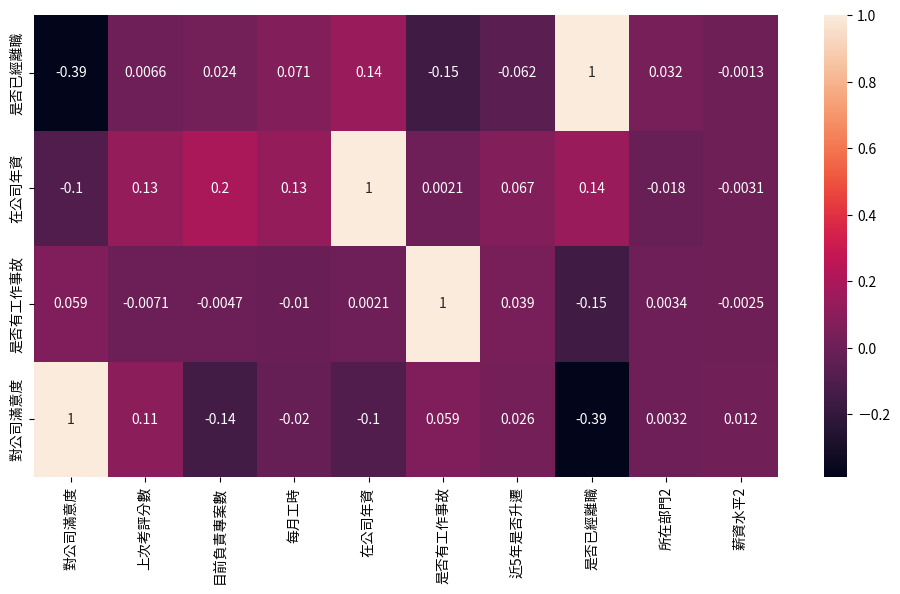

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df6[a1].sort_values("是否已經離職",ascending=False),annot=True)

---
### **1-2. 針對以下指定欄位畫出配對圖，並用標註調色盤**

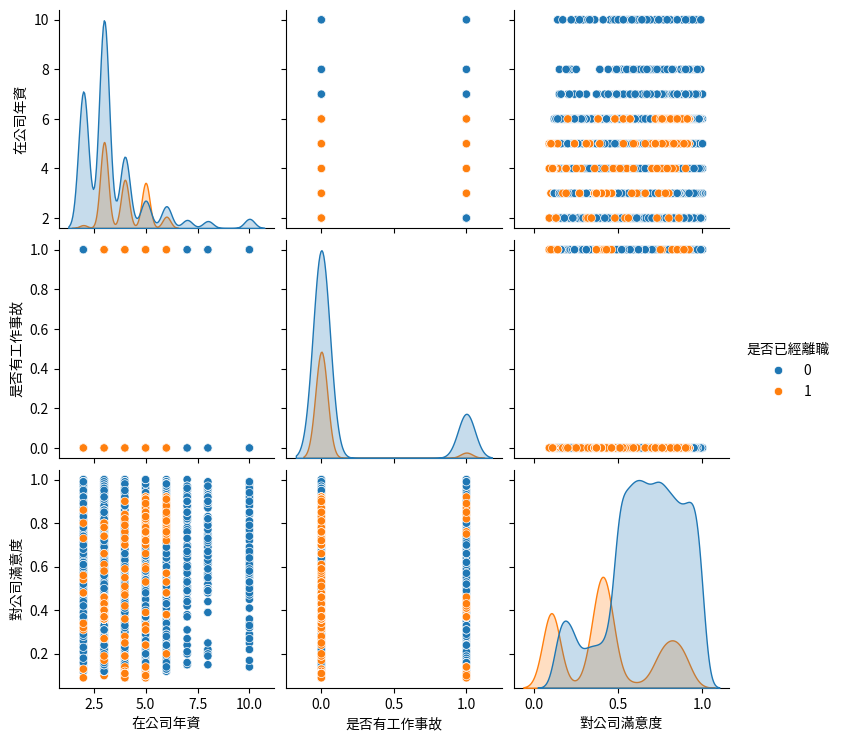

In [ ]:
sns.pairplot(df5,vars=["在公司年資","是否有工作事故","對公司滿意度"],hue="是否已經離職")

---
###**1-3. 畫出2個欄位【對公司滿意度，在公司年資】的配對圖，用第3個欄位【是否已經離職】來配色**

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


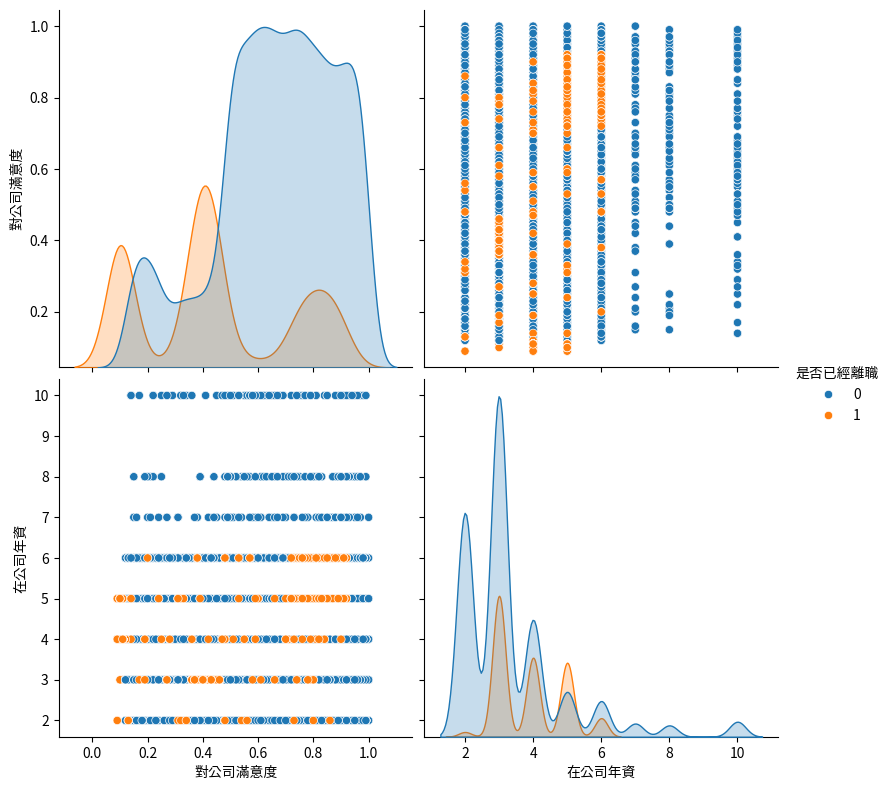

In [ ]:
sns.pairplot(df5,vars=["對公司滿意度","在公司年資"],hue="是否已經離職",size=4)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


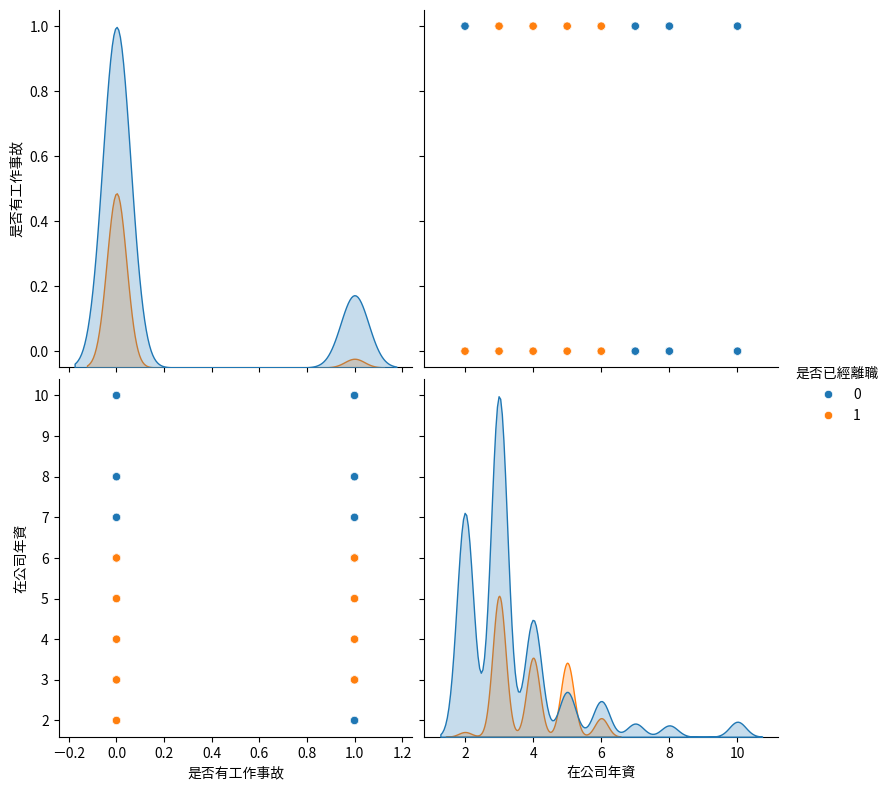

In [ ]:
#依照下方答案
sns.pairplot(df5,vars=["是否有工作事故","在公司年資"],hue="是否已經離職",size=4)

---
###**1-4. 畫出1個欄位【對公司滿意度】的數據分佈圖，並用欄位【是否已經離職】來標註顏色**

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


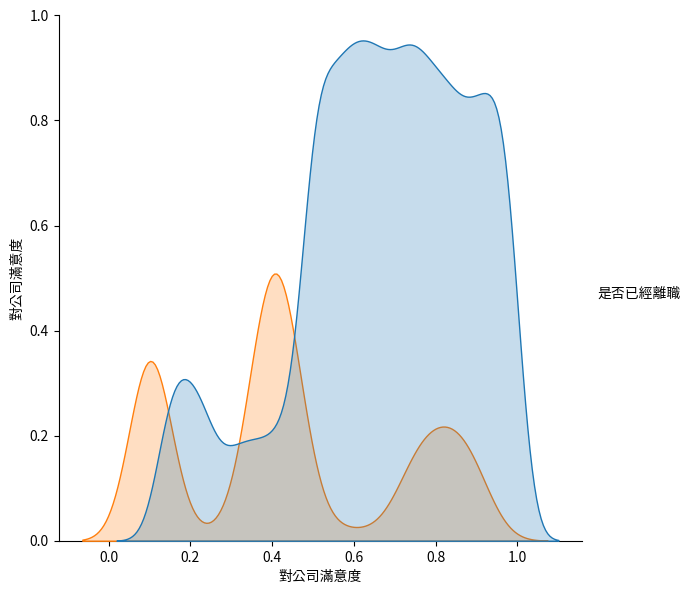

In [ ]:
sns.pairplot(df5,vars=["對公司滿意度"],hue="是否已經離職",size=6)

---
### **1-5. 畫出【對公司滿意度 vs 是否已經離職】的點狀圖**
請用不同顏色，標註"是否已經離職"，並用 seaborn 模組來畫圖。



<Axes: xlabel='對公司滿意度', ylabel='是否已經離職'>

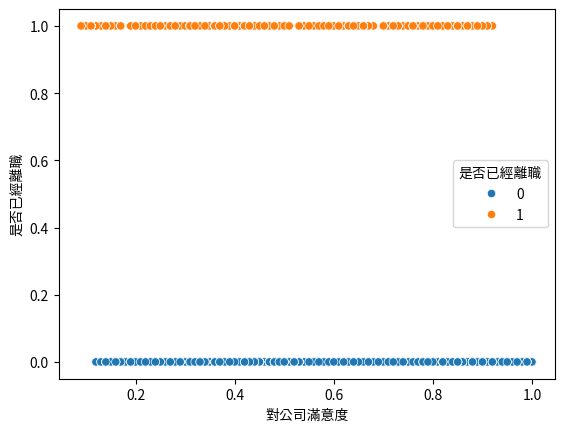

In [ ]:
sns.scatterplot(df5,x="對公司滿意度",y="是否已經離職",hue="是否已經離職")

---
###**1-6. 用扇形圖畫出【是否已經離職】的佔比**
0：沒有離職

1：已經離職



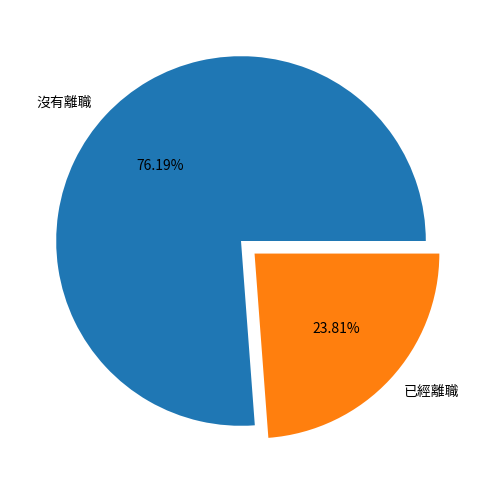

In [ ]:
df7 = df5['是否已經離職'].value_counts(normalize=True)
plt.figure(figsize=(12,6))
plt.pie(df7,labels=["沒有離職","已經離職"],autopct="%.2f%%",explode=[0,0.1])
plt.show()

---
##**2. 讀入『A商城會員資料集』，請做自動分群，將之分成5種會員屬性，請分出來？並作預測。**
案例資料集選自Kaggle：商城使用者細分數據(Mall Customer Segmentation Data)
基於某一家商城會員的基本資料，由各種特徵欄位，來進行客戶細分，以便可以給行銷團隊進一步制定決策提供依據。

###將商城會員分為如下聚類/分群：
•	謹慎消費者（高收入且低消費的客戶）

•	標準消費者（與其他客戶相比，擁有平均收入和平均消費的客戶）

•	目標消費者（高收入且高消費的客戶）

•	非理性消費者（收入少且高消費的客戶）

•	理性消費者（低收入且低消費的客戶）

---
###這是一個關於商場顧客的資料集，它包含了 200 個顧客的 4 個特徵，特徵欄位分別是【性別、年齡、年收入，消費得分】

消費得分是根據顧客的消費行為和購買力給出的一個數值，越高表示越有可能成為忠實的顧客。

我們可以用這個資料集來做聚類分析，看看能否將顧客分成不同的市場區隔，並根據他們的特徵和消費得分來制定相應的行銷策略。

---
###已知下方的特徵欄位，對應的客戶分群標籤：
•	【Male, 32, 137, 18】：謹慎消費者（高收入且低消費的客戶）

•	【Female, 29, 40, 42】：標準消費者（與其他客戶相比，擁有平均收入和平均消費的客戶）

•	【Male, 30, 137, 83】：目標消費者（高收入且高消費的客戶）

•	【Male, 21, 15, 81】：非理性消費者（收入少且高消費的客戶）

•	【Female, 20, 16, 6】： 理性消費者（低收入且低消費的客戶）

###請自行由此來驗證並判別你的自動分群的編號所對應之品種。

---
數據集檔案：
https://acupun.site/lecture/predict/example/resource/Mall_Customers_chi.csv


In [ ]:
df = pd.read_csv("https://acupun.site/lecture/predict/example/resource/Mall_Customers_chi.csv")
df

,客戶ID,性別,年齡,年收入,消費得分
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df2 = df.replace("Male",1).replace("Female",2)
df2

/tmp/ipython-input-2796262932.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2 = df.replace("Male",1).replace("Female",2)


,客戶ID,性別,年齡,年收入,消費得分
0,1,1,19,15,39
1,2,1,21,15,81
2,3,2,20,16,6
3,4,2,23,16,77
4,5,2,31,17,40
...,...,...,...,...,...
195,196,2,35,120,79
196,197,2,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [ ]:
import sklearn.cluster as cluster
model = cluster.KMeans(n_clusters=5,random_state=200)
model.fit(df2[["性別","年齡","年收入","消費得分"]])
model.labels_

array([3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 4, 0, 1, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0], dtype=int32)

In [ ]:
#【Male, 32, 137, 18】：謹慎消費者（高收入且低消費的客戶）4

#【Female, 29, 40, 42】：標準消費者（與其他客戶相比，擁有平均收入和平均消費的客戶）1

#【Male, 30, 137, 83】：目標消費者（高收入且高消費的客戶）0

#【Male, 21, 15, 81】：非理性消費者（收入少且高消費的客戶）2

#【Female, 20, 16, 6】： 理性消費者（低收入且低消費的客戶）3

In [ ]:
model.predict([[1, 32, 137, 18]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

In [ ]:
model.predict([[2, 29, 40, 42]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([1], dtype=int32)

In [ ]:
model.predict([[1, 30, 137, 83]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

In [ ]:
model.predict([[1, 21, 15, 81]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

In [ ]:
model.predict([[2, 20, 16, 6]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([3], dtype=int32)

In [ ]:
#請做預測1:A客戶的特徵值【性別，年齡，年收入，消費得分】
#=【Male, 59, 43, 60】，請問A客戶的屬性歸類？
if model.predict([[1, 59, 43, 60]])[0] ==0:
  print("他是：目標消費者（高收入且高消費的客戶）")
elif model.predict([[1, 59, 43, 60]])[0] ==1:
  print("他是：標準消費者（與其他客戶相比，擁有平均收入和平均消費的客戶）")
elif model.predict([[1, 59, 43, 60]])[0] ==2:
  print("他是：非理性消費者（收入少且高消費的客戶）")
elif model.predict([[1, 59, 43, 60]])[0] ==3:
  print("他是：理性消費者（低收入且低消費的客戶）")
elif model.predict([[1, 59, 43, 60]])[0] ==4:
  print("他是：謹慎消費者（高收入且低消費的客戶）")

他是：標準消費者（與其他客戶相比，擁有平均收入和平均消費的客戶）


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
#請做預測2:B客戶的特徵值【性別，年齡，年收入，消費得分】
#=【Female,34,103,23】，請問B客戶的屬性歸類？
if model.predict([[2,34,103,23]])[0] ==0:
  print("他是：目標消費者（高收入且高消費的客戶）")
elif model.predict([[2,34,103,23]])[0] ==1:
  print("他是：標準消費者（與其他客戶相比，擁有平均收入和平均消費的客戶）")
elif model.predict([[2,34,103,23]])[0] ==2:
  print("他是：非理性消費者（收入少且高消費的客戶）")
elif model.predict([[2,34,103,23]])[0] ==3:
  print("他是：理性消費者（低收入且低消費的客戶）")
elif model.predict([[2,34,103,23]])[0] ==4:
  print("他是：謹慎消費者（高收入且低消費的客戶）")

他是：謹慎消費者（高收入且低消費的客戶）


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
#請做預測3:C客戶的特徵值【性別，年齡，年收入，消費得分】
#=【Male, 30, 99, 97】，請問C客戶的屬性歸類？
if model.predict([[1, 30, 99, 97]])[0] ==0:
  print("他是：目標消費者（高收入且高消費的客戶）")
elif model.predict([[1, 30, 99, 97]])[0] ==1:
  print("他是：標準消費者（與其他客戶相比，擁有平均收入和平均消費的客戶）")
elif model.predict([[1, 30, 99, 97]])[0] ==2:
  print("他是：非理性消費者（收入少且高消費的客戶）")
elif model.predict([[1, 30, 99, 97]])[0] ==3:
  print("他是：理性消費者（低收入且低消費的客戶）")
elif model.predict([[1, 30, 99, 97]])[0] ==4:
  print("他是：謹慎消費者（高收入且低消費的客戶）")

他是：目標消費者（高收入且高消費的客戶）


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


---
##**3. 用sklearn模組，建立『KNN』演算法來預測鐵達尼號乘客是否會存活？**

###**注意：請回答【會生存，不會生存】，不要回答 0/1。**
---
資料集檔案：
https://acupun.site/lecture/predict/example/resource/titanic_pre-chi.xlsx

資料表：data

特徵欄位：乘客等級，年齡，性別

標籤label欄位：是否生存

0：亡

1：生存



In [ ]:
import pandas as pd
df = pd.read_excel("https://acupun.site/lecture/predict/example/resource/titanic_pre-chi.xlsx","data")
df

,乘客編號,姓名,乘客等級,年齡,性別,是否生存
0,1,"Allen, Miss Elisabeth Walton",1st,29.00,female,1
1,2,"Allison, Miss Helen Loraine",1st,2.00,female,0
2,3,"Allison, Mr Hudson Joshua Creighton",1st,30.00,male,0
3,4,"Allison, Mrs Hudson JC (Bessie Waldo Daniels)",1st,25.00,female,0
4,5,"Allison, Master Hudson Trevor",1st,0.92,male,1
...,...,...,...,...,...,...
1308,1309,"Zakarian, Mr Artun",3rd,27.00,male,0
1309,1310,"Zakarian, Mr Maprieder",3rd,26.00,male,0
1310,1311,"Zenni, Mr Philip",3rd,22.00,male,0
1311,1312,"Lievens, Mr Rene",3rd,24.00,male,0


In [ ]:
df2 = df.replace("1st",1).replace("2nd",2).replace("3rd",3).replace("male",1).replace("female",2)
df2

/tmp/ipython-input-3236881302.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2 = df.replace("1st",1).replace("2nd",2).replace("3rd",3).replace("male",1).replace("female",2)


,乘客編號,姓名,乘客等級,年齡,性別,是否生存
0,1,"Allen, Miss Elisabeth Walton",1,29.00,2,1
1,2,"Allison, Miss Helen Loraine",1,2.00,2,0
2,3,"Allison, Mr Hudson Joshua Creighton",1,30.00,1,0
3,4,"Allison, Mrs Hudson JC (Bessie Waldo Daniels)",1,25.00,2,0
4,5,"Allison, Master Hudson Trevor",1,0.92,1,1
...,...,...,...,...,...,...
1308,1309,"Zakarian, Mr Artun",3,27.00,1,0
1309,1310,"Zakarian, Mr Maprieder",3,26.00,1,0
1310,1311,"Zenni, Mr Philip",3,22.00,1,0
1311,1312,"Lievens, Mr Rene",3,24.00,1,0


In [ ]:
import pandas as pd
import sklearn.neighbors as nb
model = nb.KNeighborsClassifier(10)
model.fit(df2[["乘客等級","年齡","性別"]],df2["是否生存"])

KNeighborsClassifier(n_neighbors=10)

In [ ]:
#3-1.預測【乘客等級,年齡,性別】 = 【1st, 30, female】是否生存？
if model.predict([[1,30,2]])[0] ==0:
  print("不會生存")
elif model.predict([[1,30,2]])[0] ==1:
  print("會生存")

會生存


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#3-2.預測【乘客等級,年齡,性別】 = 【3rd, 31, male】是否生存？
if model.predict([[3,31,1]])[0] ==0:
  print("不會生存")
elif model.predict([[3,31,1]])[0] ==1:
  print("會生存")

不會生存


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#3-3.預測【乘客等級,年齡,性別】 = 【2nd, 27, male】是否生存？
if model.predict([[2,27,1]])[0] ==0:
  print("不會生存")
elif model.predict([[2,27,1]])[0] ==1:
  print("會生存")

不會生存


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


---
##**4. 利用『LabelEncoder』處理『由症狀判讀用藥資料集』的文字欄位，並用『sklearn的KNN模型』來預測用藥。**
讀入『由症狀判讀用藥資料集』
https://acupun.site/lecture/predict/example/resource/drug200-chi.csv

---
###**4-1. 必須用LabelEncode()來轉換文字欄位**

*   DrugY --> 0
*   drugA --> 1
*   drugB --> 2
*   drugC --> 3
*   drugX --> 4

In [ ]:
#轉換後印出前50筆數據
df2 = pd.read_csv("https://acupun.site/lecture/predict/example/resource/drug200-chi.csv")
df2["血壓2"] = prep.LabelEncoder().fit_transform(df2["血壓"])
df2["膽固醇2"] = prep.LabelEncoder().fit_transform(df2["膽固醇"])
df2["性別2"] = prep.LabelEncoder().fit_transform(df2["性別"])
df2["用藥2"] = prep.LabelEncoder().fit_transform(df2["用藥"])
df2.head(50)

,年齡,性別,血壓,膽固醇,血液鈉鉀比例,用藥,血壓2,膽固醇2,性別2,用藥2
0,23,F,HIGH,HIGH,25.355,DrugY,0,0,0,0
1,47,M,LOW,HIGH,13.093,drugC,1,0,1,3
2,47,M,LOW,HIGH,10.114,drugC,1,0,1,3
3,28,F,NORMAL,HIGH,7.798,drugX,2,0,0,4
4,61,F,LOW,HIGH,18.043,DrugY,1,0,0,0
5,22,F,NORMAL,HIGH,8.607,drugX,2,0,0,4
6,49,F,NORMAL,HIGH,16.275,DrugY,2,0,0,0
7,41,M,LOW,HIGH,11.037,drugC,1,0,1,3
8,60,M,NORMAL,HIGH,15.171,DrugY,2,0,1,0
9,43,M,LOW,NORMAL,19.368,DrugY,1,1,1,0


In [ ]:
#--------------------------------------
# colab繪圖顯示繁體中文
#--------------------------------------
import matplotlib
#colab顯示繁體中文 問題：matplotlib繪圖，會發生中文無法顯示的問題
# 先下載台北黑體字型
!wget -O taipei_sans_tc_beta.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download import matplotlib
# 新增字體
matplotlib.font_manager.fontManager.addfont('taipei_sans_tc_beta.ttf')
# 將 font-family 設為 Taipei Sans TC Beta
# 設定完後，之後的圖表都可以顯示中文了
matplotlib.rc('font', family='Taipei Sans TC Beta')

/bin/bash: line 1: import: command not found
--2026-01-08 06:39:16--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 142.250.101.138, 142.250.101.139, 142.250.101.113, ...
Connecting to drive.google.com (drive.google.com)|142.250.101.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-01-08 06:39:16--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.2.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘taipei_sans_tc_beta.ttf’

taipei_sans_tc_beta 100%[===================>]  19.70M  

---
###**4-2. 請用熱圖表示本資料集的關聯度，依照【用藥】欄位排序（高到低）**

In [ ]:
df3 = df2.drop(["性別","血壓","膽固醇","用藥"],axis="columns")
df3

,年齡,血液鈉鉀比例,血壓2,膽固醇2,性別2,用藥2
0,23,25.355,0,0,0,0
1,47,13.093,1,0,1,3
2,47,10.114,1,0,1,3
3,28,7.798,2,0,0,4
4,61,18.043,1,0,0,0
...,...,...,...,...,...,...
195,56,11.567,1,0,0,3
196,16,12.006,1,0,1,3
197,52,9.894,2,0,1,4
198,23,14.020,2,1,1,4


<Axes: >

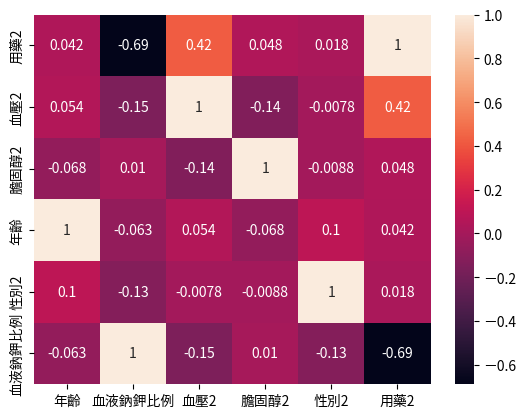

In [ ]:
sns.heatmap(df3.corr().sort_values("用藥2",ascending=False),annot=True)

---
###**4-3. 評估AI模型的成效，並畫出【混淆矩陣圖】**

In [ ]:
df3

,年齡,血液鈉鉀比例,血壓2,膽固醇2,性別2,用藥2
0,23,25.355,0,0,0,0
1,47,13.093,1,0,1,3
2,47,10.114,1,0,1,3
3,28,7.798,2,0,0,4
4,61,18.043,1,0,0,0
...,...,...,...,...,...,...
195,56,11.567,1,0,0,3
196,16,12.006,1,0,1,3
197,52,9.894,2,0,1,4
198,23,14.020,2,1,1,4


In [ ]:
import sklearn.neighbors as kn
model = kn.KNeighborsClassifier(n_neighbors=7)
X_train, X_test, y_train, y_test = ms.train_test_split(
    df3[["年齡","性別2","血壓2","膽固醇2","血液鈉鉀比例"]], df3["用藥2"],test_size=0.3)

In [ ]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

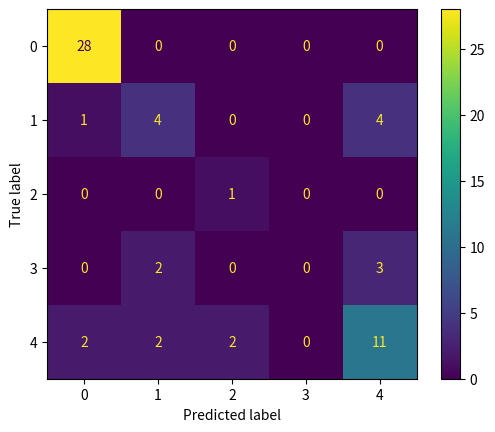

In [ ]:
y_pred = model.predict(X_test)
mts.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

---
###**4-4. 計算本AI模型的準確度(使用測試數據)**

In [ ]:
model.score(X_train,y_train)

0.7428571428571429

In [ ]:
model.score(X_test,y_test)

0.7333333333333333

---
###**4-5. 評估本AI模型是否有發生overfitting的現象(有/沒有)？**

In [ ]:
'沒有'

---
###**4-6. 請做預測，當A患者的5個特徵值是：【年齡，性別，血壓，膽固醇，血液鈉鉀比例】=【48，F，LOW，HIGH，15.036】，請問A患者該用什麼藥品？（答案不要寫數字，請寫藥品名稱：DrugC，DrugX，DrugY.....）**

In [ ]:
df2.head(50)

,年齡,性別,血壓,膽固醇,血液鈉鉀比例,用藥,血壓2,膽固醇2,性別2,用藥2
0,23,F,HIGH,HIGH,25.355,DrugY,0,0,0,0
1,47,M,LOW,HIGH,13.093,drugC,1,0,1,3
2,47,M,LOW,HIGH,10.114,drugC,1,0,1,3
3,28,F,NORMAL,HIGH,7.798,drugX,2,0,0,4
4,61,F,LOW,HIGH,18.043,DrugY,1,0,0,0
5,22,F,NORMAL,HIGH,8.607,drugX,2,0,0,4
6,49,F,NORMAL,HIGH,16.275,DrugY,2,0,0,0
7,41,M,LOW,HIGH,11.037,drugC,1,0,1,3
8,60,M,NORMAL,HIGH,15.171,DrugY,2,0,1,0
9,43,M,LOW,NORMAL,19.368,DrugY,1,1,1,0


In [ ]:
'''
由LabelEncoder轉換的欄位得知：
血壓：High 0 Low 1 Normal 2
膽固醇：High 0 Normal 1 Low 2
性別：F 0 M 1
用藥：Y0 A1 B2 C3 X4
'''

In [ ]:
print(model.predict([[48,0,1,0,15.036]]))

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
'A患者該使用藥品 = DrugY'

###**4-7. 回答準確率相關的3個問題：**

###**4-7-1. 哪一種類的樣本(0,1,2,3,4)，被猜中率最高？**

###**4-7-2. 全部樣本的整體被猜中率為多少？**

###**4-7-3. AI模型的預測準確率，最高的，是針對哪一種樣本(0,1,2,3,4)的預測**



In [ ]:
print(mts.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        28
           1       0.50      0.44      0.47         9
           2       0.33      1.00      0.50         1
           3       0.00      0.00      0.00         5
           4       0.61      0.65      0.63        17

    accuracy                           0.73        60
   macro avg       0.47      0.62      0.51        60
weighted avg       0.68      0.73      0.70        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


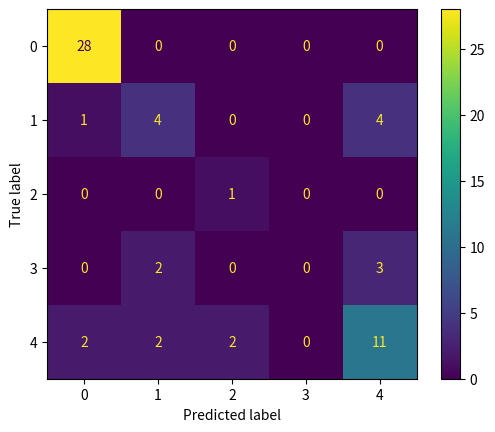

In [ ]:
mts.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

**4-7-1. 哪一種類的樣本(0,1,2,3,4)，被猜中率最高？**

A：0跟2

**4-7-2. 全部樣本的整體被猜中率為多少？**

A：0.73

**4-7-3. AI模型的預測準確率，最高的，是針對哪一種樣本(0,1,2,3,4)的預測**

A：0

---
##**5. 請讀入以下的csv檔案，用多項式預測，比較【4種的多項式預測線】**
###**（其中，第4種多項式預測線，必須最接近原始數據）**

資料集檔案：https://acupun.site/lecture/predict/example/resource/curve-3.csv

In [ ]:
#--------------------------------------
# colab繪圖顯示繁體中文
#--------------------------------------
import matplotlib
#colab顯示繁體中文 問題：matplotlib繪圖，會發生中文無法顯示的問題
# 先下載台北黑體字型
!wget -O taipei_sans_tc_beta.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download import matplotlib
# 新增字體
matplotlib.font_manager.fontManager.addfont('taipei_sans_tc_beta.ttf')
# 將 font-family 設為 Taipei Sans TC Beta
# 設定完後，之後的圖表都可以顯示中文了
matplotlib.rc('font', family='Taipei Sans TC Beta')

/bin/bash: line 1: import: command not found
--2025-11-06 05:38:53--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 74.125.24.100, 74.125.24.139, 74.125.24.113, ...
Connecting to drive.google.com (drive.google.com)|74.125.24.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2025-11-06 05:38:53--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.10.132, 2404:6800:4003:c0f::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.10.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘taipei_sans_tc_beta.ttf’

taipei_sans_tc_beta 100%[===================>]  19.70M  --.-KB

In [ ]:
import pandas as pd
df = pd.read_csv("https://acupun.site/lecture/predict/example/resource/curve-3.csv")
df

,x,y
0,0.000000,-0.298148
1,0.001001,-0.290418
2,0.002002,-0.275903
3,0.003003,-0.313167
4,0.004004,-0.315493
...,...,...
995,0.995996,0.275279
996,0.996997,0.309969
997,0.997998,0.362625
998,0.998999,0.323311


In [ ]:
import sklearn.preprocessing as prep
#第一種
model1 = prep.PolynomialFeatures(degree=10)
X_poly = model1.fit_transform(df[["x"]])
import sklearn.linear_model as lm
model2 = lm.LinearRegression()
model2.fit(X_poly, df["y"])

#第二種
model3 = prep.PolynomialFeatures(degree=15)
X_poly = model3.fit_transform(df[["x"]])
import sklearn.linear_model as lm
model4 = lm.LinearRegression()
model4.fit(X_poly, df["y"])

#第三種
model5 = prep.PolynomialFeatures(degree=20)
X_poly = model5.fit_transform(df[["x"]])
import sklearn.linear_model as lm
model6 = lm.LinearRegression()
model6.fit(X_poly, df["y"])

#第四種
model7 = prep.PolynomialFeatures(degree=30)
X_poly = model7.fit_transform(df[["x"]])
import sklearn.linear_model as lm
model8 = lm.LinearRegression()
model8.fit(X_poly, df["y"])

LinearRegression()

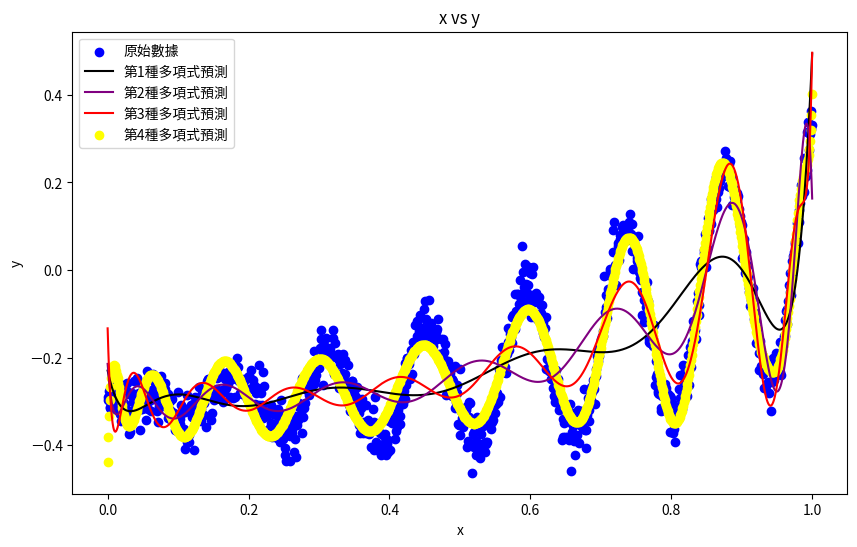

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(df["x"],df["y"],color="blue",label="原始數據")
plt.plot(df["x"],model2.predict(model1.fit_transform(df[["x"]])),color="black",label="第1種多項式預測")
plt.plot(df["x"],model4.predict(model3.fit_transform(df[["x"]])),color="purple",label="第2種多項式預測")
plt.plot(df["x"],model6.predict(model5.fit_transform(df[["x"]])),color="red",label="第3種多項式預測")
plt.scatter(df["x"],model8.predict(model7.fit_transform(df[["x"]])),color="yellow",label="第4種多項式預測")
plt.title("x vs y")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

##**6. 請用深度學習（多顆類神經網絡）來學習以下的csv檔案，並畫出『非線性迴歸線』**
##**請預測當x=1，y=？**

資料集檔案：https://acupun.site/lecture/predict/example/resource/curve-3.csv

In [ ]:
import pandas as pd
df = pd.read_csv("https://acupun.site/lecture/predict/example/resource/curve-3.csv")
df

,x,y
0,0.000000,-0.298148
1,0.001001,-0.290418
2,0.002002,-0.275903
3,0.003003,-0.313167
4,0.004004,-0.315493
...,...,...
995,0.995996,0.275279
996,0.996997,0.309969
997,0.997998,0.362625
998,0.998999,0.323311


In [ ]:
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=128,input_dim=1,activation="relu"),
    tf.keras.layers.Dense(units=64,activation="relu"),
    tf.keras.layers.Dense(units=1)
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.MeanSquaredError()]
)
model.fit(df[["x"]],df["y"],epochs=2000)

Epoch 1/2000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0566 - mean_squared_error: 0.0566
Epoch 2/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0252 - mean_squared_error: 0.0252
Epoch 3/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0154 - mean_squared_error: 0.0154
Epoch 4/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0167 - mean_squared_error: 0.0167
Epoch 5/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0170 - mean_squared_error: 0.0170
Epoch 6/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0170 - mean_squared_error: 0.0170
Epoch 7/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0156 - mean_squared_error: 0.0156
Epoch 8/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0154 - mean_squared_error: 0.0154
Epoch 9/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0152 - mean_squared_error: 0.0152
Epoch 10/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0158 - mean_squared_error: 0.0158
Epoch 11/2000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

In [ ]:
model.predict(pd.DataFrame([[1]]))[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


array([0.33575436], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


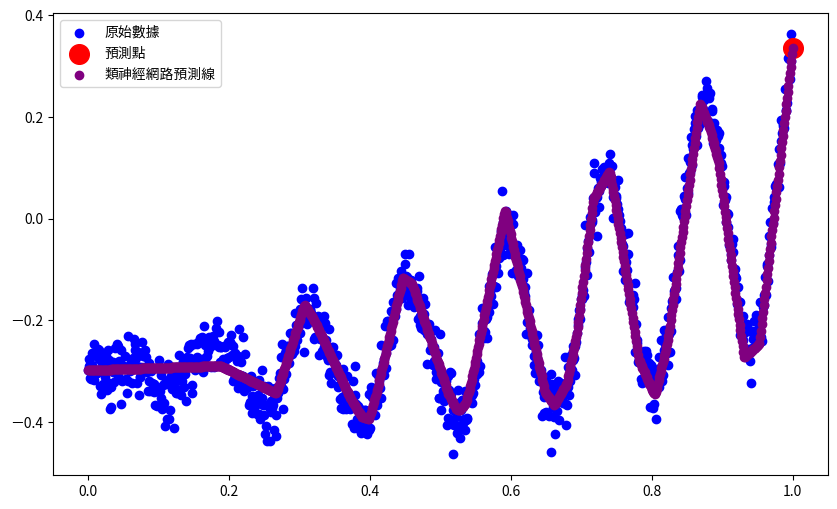

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(df["x"],df["y"],color="blue",label="原始數據")
plt.scatter(pd.DataFrame([[1]]),model.predict(pd.DataFrame([[1]])),s=200,color="red",label="預測點")
plt.scatter(df["x"],model.predict(df[["x"]]),color="purple",label="類神經網路預測線")
plt.legend()

---
##**7. 讀入紅酒數據，測試3種機器學習演算法【KNN，決策樹，隨機森林法】，找出【測試數據】所得到準確率最高的一種演算法，並印出其Accuracy**
https://acupun.site/lecture/predict/example/resource/wine-chi-1.csv

wine.target 有三種酒類：

1. Barolo

2. Grignolino

3. Barbera

In [ ]:
#--------------------------------------
# colab繪圖顯示繁體中文
#--------------------------------------
import matplotlib
#colab顯示繁體中文 問題：matplotlib繪圖，會發生中文無法顯示的問題
# 先下載台北黑體字型
!wget -O taipei_sans_tc_beta.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download import matplotlib
# 新增字體
matplotlib.font_manager.fontManager.addfont('taipei_sans_tc_beta.ttf')
# 將 font-family 設為 Taipei Sans TC Beta
# 設定完後，之後的圖表都可以顯示中文了
matplotlib.rc('font', family='Taipei Sans TC Beta')

/bin/bash: line 1: import: command not found
--2026-01-08 05:48:48--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 142.250.101.138, 142.250.101.100, 142.250.101.101, ...
Connecting to drive.google.com (drive.google.com)|142.250.101.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-01-08 05:48:48--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘taipei_sans_tc_beta.ttf’

taipei_sans_tc_beta 100%[===================>]  19.7

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('https://acupun.site/lecture/predict/example/resource/wine-chi-1.csv')
df

,酒精濃度,蘋果酸,灰,灰的鹼度,鎂,總酚,黃酮類化合物,非黃烷類酚類,原花青素,色彩強度,色調,稀釋酒,脯氨酸,種類
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,2
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,2
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,2
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,2


###**7-1. 用視覺化 BI 的方式，畫出【"黃酮類化合物","稀釋酒"】的迴歸線**

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


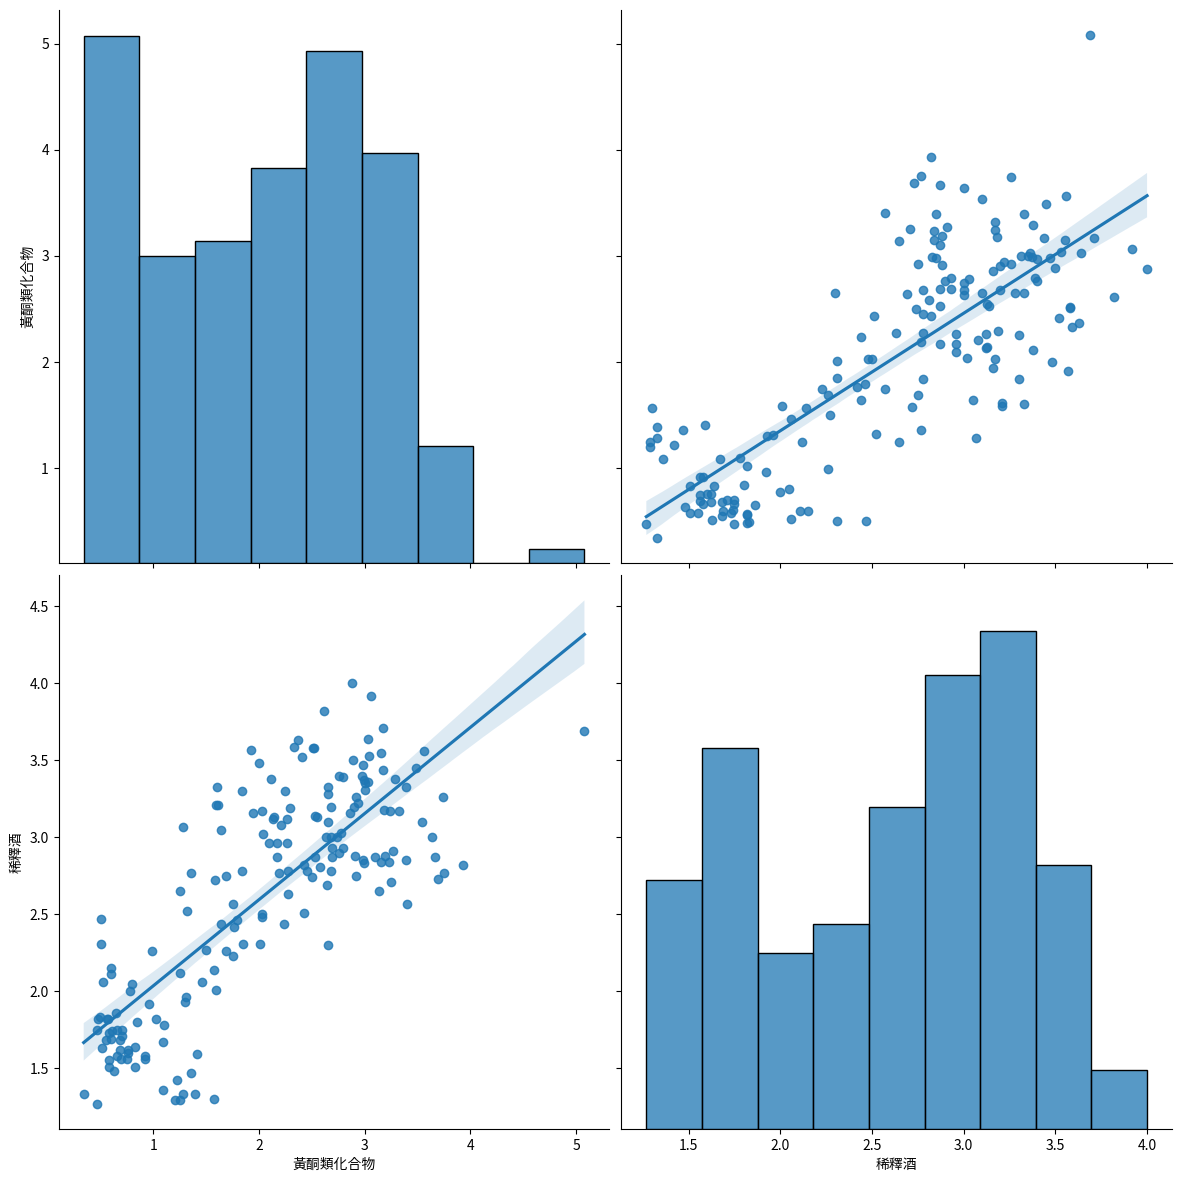

In [ ]:
sns.pairplot(df[["黃酮類化合物","稀釋酒"]],kind="reg",size=6)

###**7-2. 用視覺化 BI 的方式，以三種酒【種類】為區分，畫出三種【"黃酮類化合物","稀釋酒"】的迴歸線**

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<Figure size 1000x600 with 0 Axes>

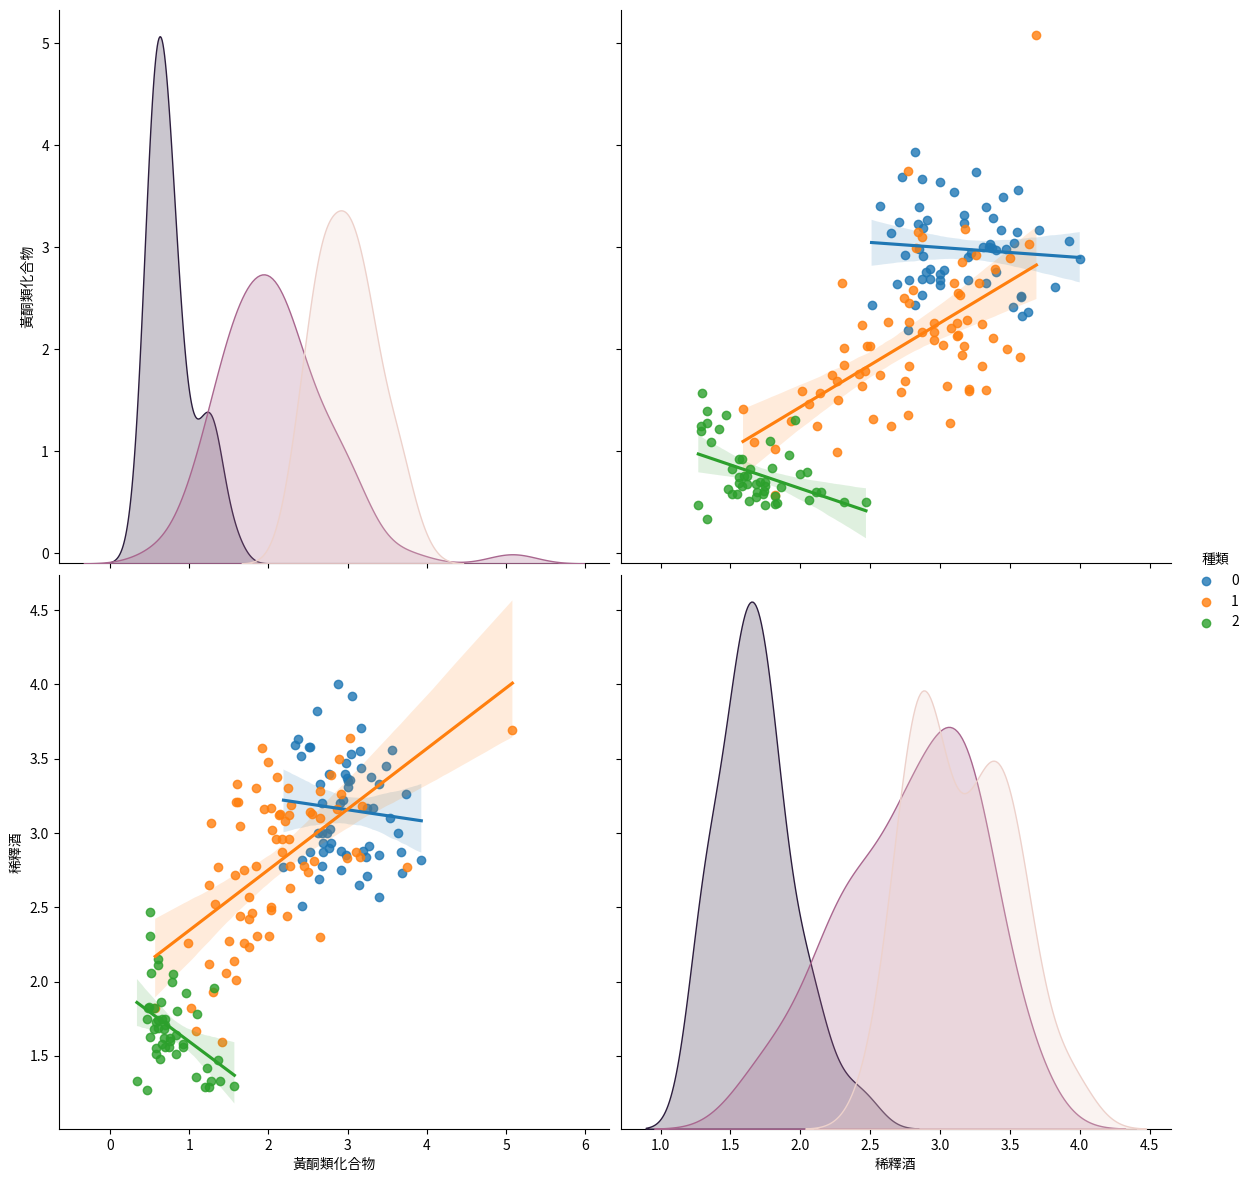

In [ ]:
sns.pairplot(df,vars=["黃酮類化合物","稀釋酒"],size=6,hue="種類",kind="reg")

###**7-3. 請畫出盒形圖來判別【"稀釋酒"，"黃酮類化合物"】數據的常態分佈**

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(df[["黃酮類化合物","稀釋酒"]])

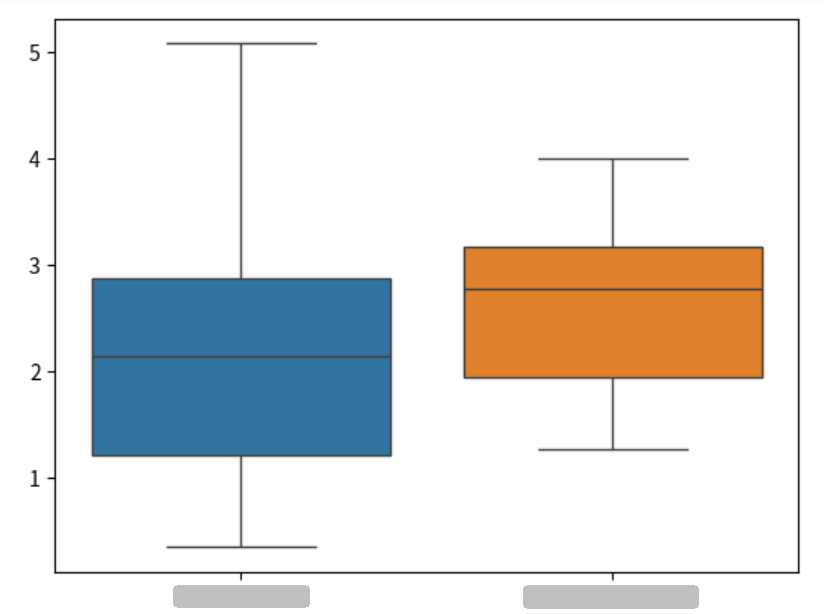

**問題：【"稀釋酒"，"黃酮類化合物"】數據，哪一個常態分佈的數據比較集中？**

A: 稀釋酒，常態分佈比較集中。

---
###**7-4. 請問3種機器學習演算法【KNN，決策樹，隨機森林法】，用測試數據計算準確率最高的，是哪一種演算法？準確率多少？（酒種必須轉成OneHotEncoder的向量方式來計算）**

In [ ]:
import sklearn.neighbors as nb
import sklearn.tree as tree
import sklearn.ensemble as esb
import sklearn.model_selection as ms
import sklearn.metrics as mts
import sklearn.preprocessing as prep

In [ ]:
arr1 = prep.OneHotEncoder(sparse_output=False).fit_transform(df[["種類"]])
arr1 = pd.DataFrame(arr1, columns =["Barolo酒","Grignolino酒","Barbera酒"])
arr1

,Barolo酒,Grignolino酒,Barbera酒
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
173,0.0,0.0,1.0
174,0.0,0.0,1.0
175,0.0,0.0,1.0
176,0.0,0.0,1.0


In [ ]:
X_train, X_test, y_train, y_test = ms.train_test_split(
    df[["稀釋酒","黃酮類化合物"]],arr1, test_size=0.2)

In [ ]:
model_kn = nb.KNeighborsClassifier(n_neighbors=10)
model_kn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
model_tree = tree.DecisionTreeClassifier()
model_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
model_rf = esb.RandomForestClassifier()
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred_kn = model_kn.predict(X_test)
y_pred_tree = model_tree.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

In [ ]:
mts.accuracy_score(y_test, y_pred_kn)

0.7777777777777778

In [ ]:
mts.accuracy_score(y_test, y_pred_tree)

0.75

In [ ]:
mts.accuracy_score(y_test, y_pred_rf)

0.8055555555555556

準確率最高的演算法 = **RandomForest 隨機森林法**

準確率 = **0.8055555555555556**

---
##**8. 請用深度學習（多顆類神經網絡），讀入紅酒數據，使用 OneHotEncoder 來編碼「種類」的全部欄位**

資料集檔案：https://acupun.site/lecture/predict/example/resource/wine-chi-4.csv


---
###**8-1. 使用 OneHotEncoder 來編碼，轉換文字種類的欄位**

In [ ]:
df8 = pd.read_csv("https://acupun.site/lecture/predict/example/resource/wine-chi-4.csv")
df8

,酒精濃度,蘋果酸,灰,灰的鹼度,鎂,總酚,黃酮類化合物,非黃烷類酚類,原花青素,色彩強度,色調,稀釋酒,脯氨酸,種類
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,Barolo酒
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,Barolo酒
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,Barolo酒
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,Barolo酒
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,Barolo酒
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,Barbera酒
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,Barbera酒
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,Barbera酒
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,Barbera酒


In [ ]:
arr2 = prep.OneHotEncoder(sparse_output=False).fit_transform(df8[["種類"]])
arr2

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1

---
###**8-2. 用 pandas 畫出訓練過程的loss/accuracy的歷史曲線**
注意：若要限制y軸顯示的範圍，請加入參數：ylim=[0,3]

In [ ]:
arr2 = pd.DataFrame(arr2, columns=["Barolo酒","Grignolino酒","Barbera酒"])
arr2

,Barolo酒,Grignolino酒,Barbera酒
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
173,1.0,0.0,0.0
174,1.0,0.0,0.0
175,1.0,0.0,0.0
176,1.0,0.0,0.0


In [ ]:
df8

,酒精濃度,蘋果酸,灰,灰的鹼度,鎂,總酚,黃酮類化合物,非黃烷類酚類,原花青素,色彩強度,色調,稀釋酒,脯氨酸,種類
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,Barolo酒
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,Barolo酒
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,Barolo酒
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,Barolo酒
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,Barolo酒
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,Barbera酒
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,Barbera酒
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,Barbera酒
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,Barbera酒


In [ ]:
X_train, X_test, y_train, y_test = ms.train_test_split(
    df8[["酒精濃度","蘋果酸","灰","灰的鹼度","鎂","總酚","黃酮類化合物","非黃烷類酚類","原花青素","色彩強度","色調","稀釋酒","脯氨酸"]],
    arr2, test_size=0.2)

In [ ]:
import tensorflow as tf
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(16, input_dim=13, activation='relu'),
  tf.keras.layers.Dense(3, activation='softmax')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[tf.keras.metrics.CategoricalAccuracy()]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(X_train,y_train,epochs=1000)

Epoch 1/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - categorical_accuracy: 0.3080 - loss: 257.1514
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.2668 - loss: 246.8433
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.2794 - loss: 226.6479
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.3406 - loss: 183.5242
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - categorical_accuracy: 0.2916 - loss: 194.1650
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.2738 - loss: 174.5588
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.3189 - loss: 145.2405
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.2482 - loss: 152.3959
Epoch 9/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.3002 - loss: 123.9512
Epoch 10/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.2736 - loss: 109.6702
Epoch 11/

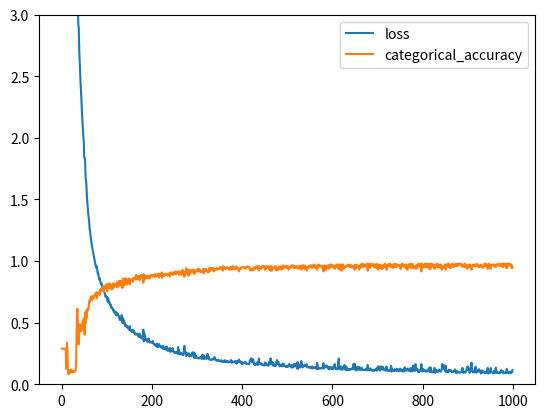

In [ ]:
plt.plot(history.history["loss"],label="loss")
plt.plot(history.history["categorical_accuracy"],label="categorical_accuracy")
plt.legend()
plt.ylim([0,3])
plt.show()

---
###**8-3. 計算本 model 的準確率accuracy（計算2個：訓練數據，測試數據）**

In [ ]:
#訓練數據的準確率= 0.9760
print("訓練數據的準確率= ", model.evaluate(X_train, y_train))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.9760 - loss: 0.0871
訓練數據的準確率=  [0.0875479206442833, 0.9788732528686523]


In [ ]:
#測試數據的準確率= 1.00
print("測試數據的準確率= ", model.evaluate(X_test, y_test))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - categorical_accuracy: 1.0000 - loss: 0.0605
測試數據的準確率=  [0.05850223824381828, 1.0]


---
###**8-4. 回答這個 model 有沒有發生overfitting的現象？**

In [ ]:
'沒有'

---
###**8-5. 讓 model 進行以下 t1 數據的預測(請回答酒種名稱，例如：Barolo，Grignolino，Barbera）**
t1 =[[13.53,	3.10,	2.74,	24.5,	96.0,	2.05,	3.76,	0.56,	1.35,	9.20,	0.61,	1.60,	560.0]]

In [ ]:
df8

,酒精濃度,蘋果酸,灰,灰的鹼度,鎂,總酚,黃酮類化合物,非黃烷類酚類,原花青素,色彩強度,色調,稀釋酒,脯氨酸,種類
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,Barolo酒
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,Barolo酒
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,Barolo酒
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,Barolo酒
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,Barolo酒
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,Barbera酒
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,Barbera酒
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,Barbera酒
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,Barbera酒


In [ ]:
t1 =[[13.53, 3.10, 2.74, 24.5, 96.0, 2.05, 3.76, 0.56, 1.35, 9.20, 0.61, 1.60, 560.0]]
print(model.predict(pd.DataFrame(t1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[0.90041536 0.07646767 0.02311689]]


**預測的酒種是 = Barolo**